# Chat ou Chien !! une méthode d'apprentissage automatique.

Dans une entreprise de marketing, on veut faire une étude sur les clients qui fréquentent un grand magasin. L'idée est d'estimer le pourcentage de clients qui ont des chats et ceux qui ont des chiens, afin de prendre des décisions marketing ciblées. Vous proposez d'utiliser une caméra pour détecter et compter les deux animaux dans le magasin. La première étape du projet est de développer un modèle qui peut détecter le chat ou le chien. Ainsi, dans ce brief, en utilisant une base de données, vous allez entrainer un modèle d'apprentissage automatique avec un apprentissage supervisé.

# Veille technologique: Opencv python

- Préparation données imagerie pour méthode classique d'apprentissage automatique
- Entrainement et évaluation (similaire aux briefs précédents)

## Operations Simples

In [1]:
# use opencv to load and display the image
import os
import cv2
import numpy as np

In [2]:
# Préparer data 
size = 64  # à la base c'était 150, mais ca prenait toute la RAM
# repertoir d'images avec deux sous dossiers "Cat" et "Dog"
image_directory = 'C:\\Users\\julyc\\OneDrive\\Bureau\\Stage\\POC\\PetImages\\'
images = []  # liste pour images  
label = []  # liste pour Label (0 ou 1) pour deux classes.

# utiliser "os" pour avoir les noms des images dans chaque sous dossier
cat_images = [f for f in os.listdir(image_directory + 'Cat\\') if f.endswith('.jpg')]
dog_images = [f for f in os.listdir(image_directory + 'Dog\\') if f.endswith('.jpg')]

print(f"Cats trouvés : {len(cat_images)}")
print(f"Dogs trouvés : {len(dog_images)}")

# utiliser une boucle pour lire chaque image, redimensionner en (150,150,3),
# et la mettre dans images, et mettre le label(0 ou 1) selon le type dans "label"

# il y a des images corrumpues, utiliser try ... catch except pour les ignorer


# boucle pour les images Cat label = 0
for img_name in cat_images:
    try:
        img = cv2.imread(image_directory + 'Cat\\' + img_name)
        img = cv2.resize(img, (size, size))
        images.append(img)
        label.append(0)
    except Exception as e:
        print(f"Image corrompue ignorée : {img_name}")

# boucle pour les images Dog label = 1
for img_name in dog_images:
    try:
        img  = cv2.imread(image_directory + 'Dog\\' + img_name)
        img = cv2.resize(img, (size, size))
        images.append(img)
        label.append(1)
    except Exception as e:
        print(f"Image corrompue ignorée : {img_name}")

# transformer les listes en numpy 
images = np.array(images)
label = np.array(label)

# save data as ".npy" file

np.save('image.npy', images)
np.save('label.npy', label)


# show shape

print(f"Images shape : {images.shape}")
print(f"Label shape : {label.shape}")

Cats trouvés : 12500
Dogs trouvés : 12499
Image corrompue ignorée : 10404.jpg
Image corrompue ignorée : 666.jpg
Image corrompue ignorée : 11702.jpg
Images shape : (24996, 64, 64, 3)
Label shape : (24996,)


In [3]:
# prepare data for classical machine learning model

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# utiliser reshape pour redimensionner les données images (exemple: (120,150,150,3) ---> (120,150*150*3)
X = images.reshape(len(images), size * size * 3)

# split les données en train et test avec "stratification"
X_train, X_test, y_train, y_test = train_test_split(
    X, label, test_size=0.2, random_state=42, stratify=label
)

In [4]:
# initialiser le classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)

# entrainer le classifier
clf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [5]:
# evaluate classifier
from sklearn.metrics import classification_report
# predire
y_pred = clf.predict(X_test)

# evaluer avec classification_report
print(classification_report(y_test, y_pred, target_names=['Cat', 'Dog']))

              precision    recall  f1-score   support

         Cat       0.64      0.70      0.67      2500
         Dog       0.67      0.61      0.64      2500

    accuracy                           0.66      5000
   macro avg       0.66      0.66      0.66      5000
weighted avg       0.66      0.66      0.66      5000



### Essayer de normaliser chaque image entre 0 et 255 et rentrainer le modèle. Y a-t-il une amélioration ?

In [6]:
import numpy as np
import cv2

X = np.load('image.npy')
label = np.load('label.npy')
size = 64

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

images_norm = []
for img in images:
    img_norm = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX)
    images_norm.append(img_norm)

images_norm = np.array(images_norm)

# Reshape
X_norm = images_norm.reshape(len(images_norm), size * size * 3)

# Split
X_train_n, X_test_n, y_train_n, y_test_n = train_test_split(
    X_norm, label, test_size=0.2, random_state=42, stratify=label
)

# Entraîner
clf_norm = RandomForestClassifier(n_estimators=100, random_state=42)
clf_norm.fit(X_train_n, y_train_n)

# Évaluer
y_pred_n = clf_norm.predict(X_test_n)
print("Avec normalisation :")
print(classification_report(y_test_n, y_pred_n, target_names=['Cat', 'Dog']))

Avec normalisation :
              precision    recall  f1-score   support

         Cat       0.64      0.71      0.68      2500
         Dog       0.68      0.60      0.64      2500

    accuracy                           0.66      5000
   macro avg       0.66      0.66      0.66      5000
weighted avg       0.66      0.66      0.66      5000



Correction Bassam pour la normalisation

In [8]:
# import cv2
# import numpy as np
# from matplotlib import pyplot as plt
 
# img = cv2.imread('100.jpg',0)
 
# hist,bins = np.histogram(img.flatten(),256,[0,256])
 
# cdf = hist.cumsum()
# cdf_normalized = cdf * hist.max()/ cdf.max()
 
# plt.plot(cdf_normalized, color = 'b')
# plt.hist(img.flatten(),256,[0,256], color = 'r')
# plt.xlim([0,256])
# plt.legend(('cdf','histogram'), loc = 'upper left')
# plt.show()

# Neural networ MLP

Entrainer un modèle MLP pour detecter la class Dog ou Cat.

In [ ]:
# use PCA to reduce dimensions
# check this tuto: https://www.askpython.com/python/examples/principal-component-analysis-for-image-data

from tensorflow.keras.layers import Input, Dense, Dropout, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report
import numpy as np

# Reshape : (n, 64, 64, 3) → (n, 67500)
# Normaliser entre 0 et 1 pour le réseau de neurones
X = images.reshape(len(images), size * size * 3)
X = X.astype(np.float32)
X /= 255.0

# Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, label, test_size=0.2, random_state=42, stratify=label
)

# Créer le MLP avec l'API fonctionnelle de Keras
inputs = Input(shape=(size * size * 3,))
x = Dense(128, activation='relu')(inputs)
x = Dense(128, activation='relu')(x)
outputs = Dense(1, activation='sigmoid')(x)

model = Model(inputs=inputs, outputs=outputs)

model.compile(
    optimizer=Adam(),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,572,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,589,633 (6.06 MB)

 Trainable params: 1,589,633 (6.06 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# entrainer le modèle avec validation_split = 0.2, epochs = 20, et un batch_size = 128
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=128
)

Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.5371 - loss: 0.7708 - val_accuracy: 0.5430 - val_loss: 0.6882
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.5708 - loss: 0.6822 - val_accuracy: 0.5750 - val_loss: 0.6741
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.5921 - loss: 0.6688 - val_accuracy: 0.6263 - val_loss: 0.6562
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.6034 - loss: 0.6606 - val_accuracy: 0.6173 - val_loss: 0.6519
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.6164 - loss: 0.6524 - val_accuracy: 0.6320 - val_loss: 0.6435
Epoch 6/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.6138 - loss: 0.6520 - val_accuracy: 0.5930 - val_loss: 0.6598
Epoch 7/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.6180 - loss: 0.6473 - val_accuracy: 0.6350 - val_loss: 0.6434
Epoch 8/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.6310 - loss: 0.6393 - val_accu

In [12]:
# evaluate MLP
# evaluate classifier
from sklearn.metrics import classification_report
# predire
y_pred_proba = model.predict(X_test)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

# evaluer avec classification_report
print(classification_report(y_test, y_pred, target_names=['Cat', 'Dog']))

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
              precision    recall  f1-score   support

         Cat       0.69      0.44      0.54      2500
         Dog       0.59      0.81      0.68      2500

    accuracy                           0.62      5000
   macro avg       0.64      0.62      0.61      5000
weighted avg       0.64      0.62      0.61      5000



C:\Users\julyc\AppData\Local\Temp\ipykernel_19816\3464142667.py:13: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(img.flatten(),256,[0,256], color = 'r')


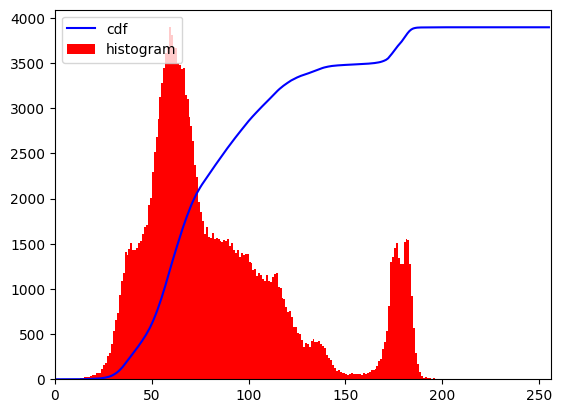

In [17]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
 
img = cv2.imread('C:\\Users\\julyc\\OneDrive\\Bureau\\Stage\\POC\\PetImages\\Dog\\100.jpg',0)
 
hist,bins = np.histogram(img.flatten(),256,[0,256])
 
cdf = hist.cumsum()
cdf_normalized = cdf * hist.max()/ cdf.max()
 
plt.plot(cdf_normalized, color = 'b')
plt.hist(img.flatten(),256,[0,256], color = 'r')
plt.xlim([0,256])
plt.legend(('cdf','histogram'), loc = 'upper left')
plt.show()

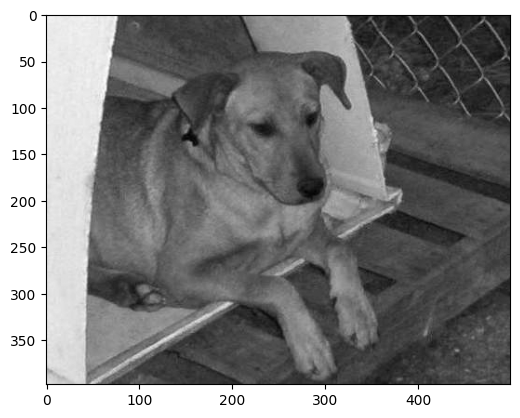

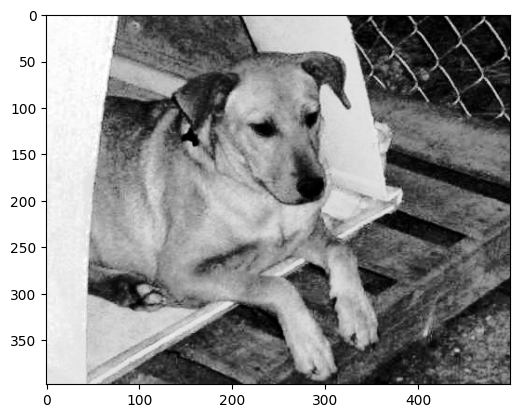

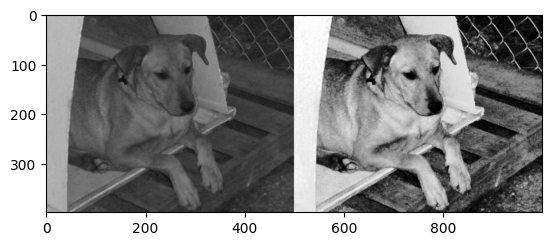

In [18]:
img = cv2.imread('C:\\Users\\julyc\\OneDrive\\Bureau\\Stage\\POC\\PetImages\\Dog\\100.jpg',0)

equ = cv2.equalizeHist(img)

res = np.hstack((img,equ)) #stacking images side-by-side

cv2.imwrite('res.png',res)
 
plt.imshow(img,cmap='gray')

plt.show()

plt.imshow(equ,cmap='gray')

plt.show()
 
img2 = cv2.imread('res.png',0)

plt.imshow(img2,cmap='gray')
 

C:\Users\julyc\AppData\Local\Temp\ipykernel_19816\1046449077.py:13: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(img.flatten(),256,[0,256], color = 'r')


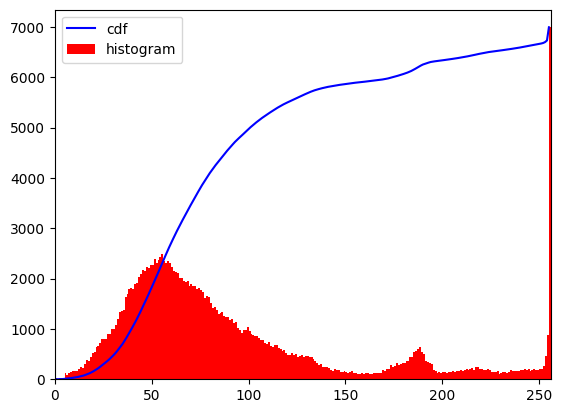

In [21]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
 
img = cv2.imread('C:\\Users\\julyc\\OneDrive\\Bureau\\Stage\\POC\\PetImages\\Cat\\12100.jpg',0)
 
hist,bins = np.histogram(img.flatten(),256,[0,256])
 
cdf = hist.cumsum()
cdf_normalized = cdf * hist.max()/ cdf.max()
 
plt.plot(cdf_normalized, color = 'b')
plt.hist(img.flatten(),256,[0,256], color = 'r')
plt.xlim([0,256])
plt.legend(('cdf','histogram'), loc = 'upper left')
plt.show()

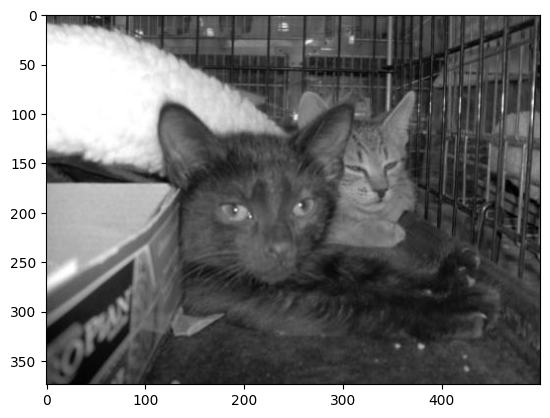

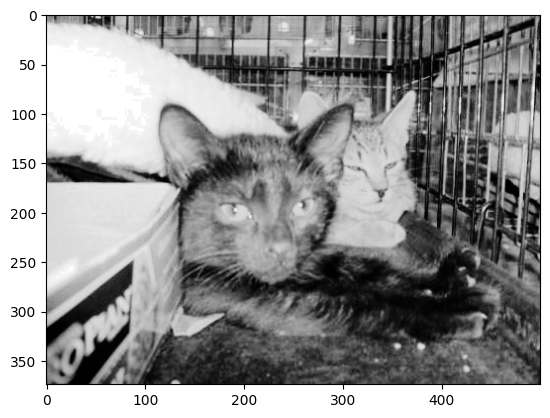

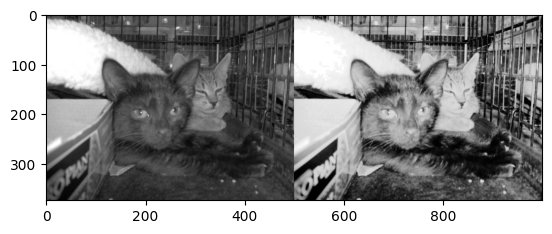

In [22]:
img = cv2.imread('C:\\Users\\julyc\\OneDrive\\Bureau\\Stage\\POC\\PetImages\\Cat\\12100.jpg',0)

equ = cv2.equalizeHist(img)

res = np.hstack((img,equ)) #stacking images side-by-side

cv2.imwrite('res.png',res)
 
plt.imshow(img,cmap='gray')

plt.show()

plt.imshow(equ,cmap='gray')

plt.show()
 
img2 = cv2.imread('res.png',0)

plt.imshow(img2,cmap='gray')

In [ ]:
C:\Users\julyc\OneDrive\Bureau\Stage\POC\PetImages\Cat\12369.jpg

C:\Users\julyc\AppData\Local\Temp\ipykernel_19816\3613665173.py:13: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(img.flatten(),256,[0,256], color = 'r')


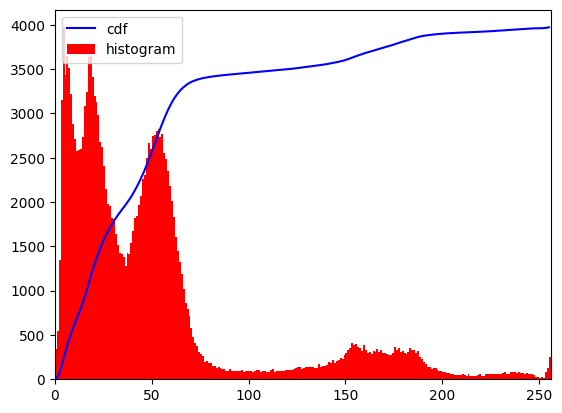

In [23]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
 
img = cv2.imread('C:\\Users\\julyc\\OneDrive\\Bureau\\Stage\\POC\\PetImages\\Cat\\12369.jpg',0)
 
hist,bins = np.histogram(img.flatten(),256,[0,256])
 
cdf = hist.cumsum()
cdf_normalized = cdf * hist.max()/ cdf.max()
 
plt.plot(cdf_normalized, color = 'b')
plt.hist(img.flatten(),256,[0,256], color = 'r')
plt.xlim([0,256])
plt.legend(('cdf','histogram'), loc = 'upper left')
plt.show()

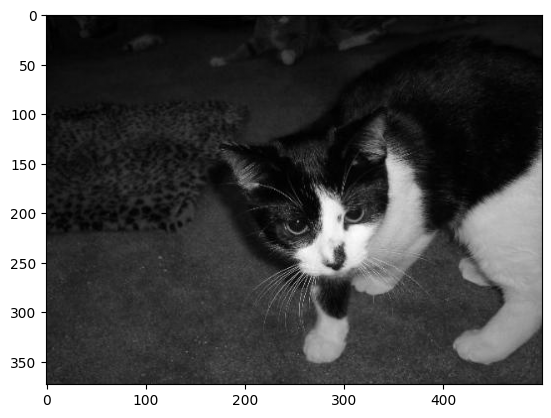

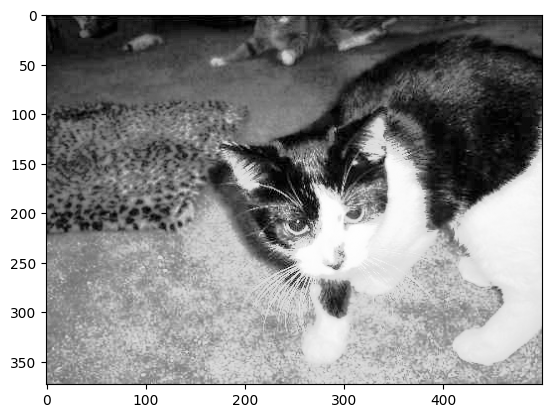

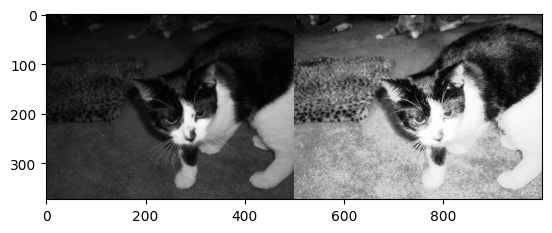

In [24]:
img = cv2.imread('C:\\Users\\julyc\\OneDrive\\Bureau\\Stage\\POC\\PetImages\\Cat\\12369.jpg',0)

equ = cv2.equalizeHist(img)

res = np.hstack((img,equ)) #stacking images side-by-side

cv2.imwrite('res.png',res)
 
plt.imshow(img,cmap='gray')

plt.show()

plt.imshow(equ,cmap='gray')

plt.show()
 
img2 = cv2.imread('res.png',0)

plt.imshow(img2,cmap='gray')